# 6. Selección del mejor modelo

**Issue:** [#6 Selección del mejor modelo](https://github.com/velascocafe23/telco-churn-mlops/issues/6)

El modelo base dejó una referencia concreta: **F1 de 0.620 sobre la clase de fuga**,
obtenida por una regresión logística con ponderación de clases. Cualquier modelo que se
elija aquí debe superarla de forma demostrable.

El procedimiento sigue el proceso manual:

1. Evaluar cinco familias distintas de modelos con validación cruzada.
2. Descartar las que rindan por debajo del promedio del conjunto.
3. Optimizar hiperparámetros de las finalistas.
4. Comparar con una prueba estadística, no por diferencia de medias.
5. Optimizar el umbral de decisión.
6. Evaluar el modelo elegido sobre el conjunto de prueba y serializarlo.

## 6.1 Configuración

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t as distribucion_t
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

INTERMEDIATE_FILE = Path("../../data/02_intermediate/telco_customer_churn.parquet")
MODELS_DIR = Path("../../models")
PREPROCESADOR_FILE = MODELS_DIR / "preprocesador.joblib"
MODELO_FILE = MODELS_DIR / "modelo_churn.joblib"
METADATOS_FILE = MODELS_DIR / "modelo_churn_metadatos.json"

IDENTIFICADOR = "customerID"
OBJETIVO = "Churn"
CLASE_POSITIVA = "Yes"

PROPORCION_PRUEBA = 0.2
SEMILLA = 42
N_PLIEGUES = 5
N_COMBINACIONES = 12
MAX_ITERACIONES = 1000
ALFA = 0.05
UMBRAL_DEFECTO = 0.5
F1_REFERENCIA = 0.620

plt.rcParams["figure.dpi"] = 100

datos = pd.read_parquet(INTERMEDIATE_FILE)
preprocesador = joblib.load(PREPROCESADOR_FILE)

atributos = datos.drop(columns=[IDENTIFICADOR, OBJETIVO])
objetivo = (datos[OBJETIVO] == CLASE_POSITIVA).astype(int)

atributos_ent, atributos_pru, objetivo_ent, objetivo_pru = train_test_split(
    atributos,
    objetivo,
    test_size=PROPORCION_PRUEBA,
    random_state=SEMILLA,
    stratify=objetivo,
)

validacion = StratifiedKFold(n_splits=N_PLIEGUES, shuffle=True, random_state=SEMILLA)

print(f"Entrenamiento: {atributos_ent.shape}")
print(f"Prueba:        {atributos_pru.shape}")
print(f"Referencia a superar: F1 = {F1_REFERENCIA}")

Entrenamiento: (5634, 19)
Prueba:        (1409, 19)
Referencia a superar: F1 = 0.62


## 6.2 Familias candidatas

Cinco familias con supuestos distintos sobre la estructura del problema. La diversidad es
deliberada: si todas fueran variantes de árboles, la comparación no informaría sobre qué
tipo de frontera de decisión conviene.

| Familia | Supuesto | Motivo de inclusión |
|---|---|---|
| Regresión logística | Frontera lineal en el espacio transformado | Es la referencia del modelo base |
| Bosque aleatorio | Particiones recursivas, captura interacciones | El EDA mostró interacción contrato-antigüedad |
| Potenciación del gradiente | Árboles secuenciales que corrigen el error previo | Familia de referencia en datos tabulares |
| Máquina de vectores de soporte | Frontera no lineal por núcleo radial | Alternativa de frontera suave |
| Vecinos más cercanos | Similitud local, sin modelo global | Contraste metodológico |

Las cuatro primeras admiten ponderacion de clases, que el modelo base mostro
determinante. La quinta no, y esa limitacion forma parte de lo que se evalua.

La maquina de vectores de soporte se instancia sin estimacion de probabilidades. Obtener
probabilidades de este modelo requiere una calibracion interna por validacion cruzada que
multiplica varias veces el costo de ajuste, y en esta etapa no hacen falta: el ROC-AUC se
calcula a partir de la funcion de decision, que ordena igual. Si esta familia quedara
seleccionada habria que envolverla en un calibrador para poder aplicar un umbral de
decision, y ese costo entraria en la comparacion operativa.

In [2]:
candidatos = {
    "logistica": LogisticRegression(
        max_iter=MAX_ITERACIONES, class_weight="balanced", random_state=SEMILLA
    ),
    "bosque": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=SEMILLA, n_jobs=-1
    ),
    "potenciacion": HistGradientBoostingClassifier(class_weight="balanced", random_state=SEMILLA),
    "svm": SVC(class_weight="balanced", random_state=SEMILLA),
    "vecinos": KNeighborsClassifier(n_jobs=-1),
}


def construir_pipeline(estimador) -> Pipeline:
    """Une el preprocesador con un estimador en un unico pipeline."""
    return Pipeline(
        steps=[
            ("preprocesamiento", preprocesador),
            ("modelo", estimador),
        ]
    )


print(f"Familias a evaluar: {list(candidatos)}")

Familias a evaluar: ['logistica', 'bosque', 'potenciacion', 'svm', 'vecinos']


## 6.3 Evaluación inicial y descarte

Todas las familias se evalúan con los mismos pliegues y con los hiperparámetros por
defecto. El objetivo no es medir su potencial máximo sino decidir cuáles merecen la
inversión de la optimización.

In [3]:
evaluaciones = []
puntajes_por_pliegue = {}

for nombre, estimador in candidatos.items():
    resultado = cross_validate(
        construir_pipeline(estimador),
        atributos_ent,
        objetivo_ent,
        cv=validacion,
        scoring=["f1", "roc_auc", "precision", "recall"],
    )
    puntajes_por_pliegue[nombre] = resultado["test_f1"]
    evaluaciones.append(
        {
            "modelo": nombre,
            "f1_media": resultado["test_f1"].mean(),
            "f1_desviacion": resultado["test_f1"].std(),
            "roc_auc": resultado["test_roc_auc"].mean(),
            "precision": resultado["test_precision"].mean(),
            "exhaustividad": resultado["test_recall"].mean(),
            "segundos_ajuste": resultado["fit_time"].mean(),
        }
    )

tabla_inicial = pd.DataFrame(evaluaciones).set_index("modelo").round(4)
tabla_inicial.sort_values("f1_media", ascending=False)

,f1_media,f1_desviacion,roc_auc,precision,exhaustividad,segundos_ajuste
modelo,,,,,,
logistica,0.6296,0.0219,0.8463,0.5199,0.7987,0.1004
potenciacion,0.6244,0.0190,0.8383,0.5432,0.7344,0.8097
svm,0.6202,0.0220,0.8257,0.5168,0.7759,0.5814
bosque,0.5988,0.0271,0.8247,0.5679,0.6334,0.6590
vecinos,0.5477,0.0177,0.7848,0.5705,0.5271,0.0383


In [4]:
promedio_f1 = tabla_inicial["f1_media"].mean()
sobrevivientes = tabla_inicial[tabla_inicial["f1_media"] >= promedio_f1].index.tolist()
descartados = [nombre for nombre in candidatos if nombre not in sobrevivientes]

print(f"F1 promedio del conjunto: {promedio_f1:.4f}")
print(f"Continúan:  {sobrevivientes}")
print(f"Descartados: {descartados}")

F1 promedio del conjunto: 0.6041
Continúan:  ['logistica', 'potenciacion', 'svm']
Descartados: ['bosque', 'vecinos']


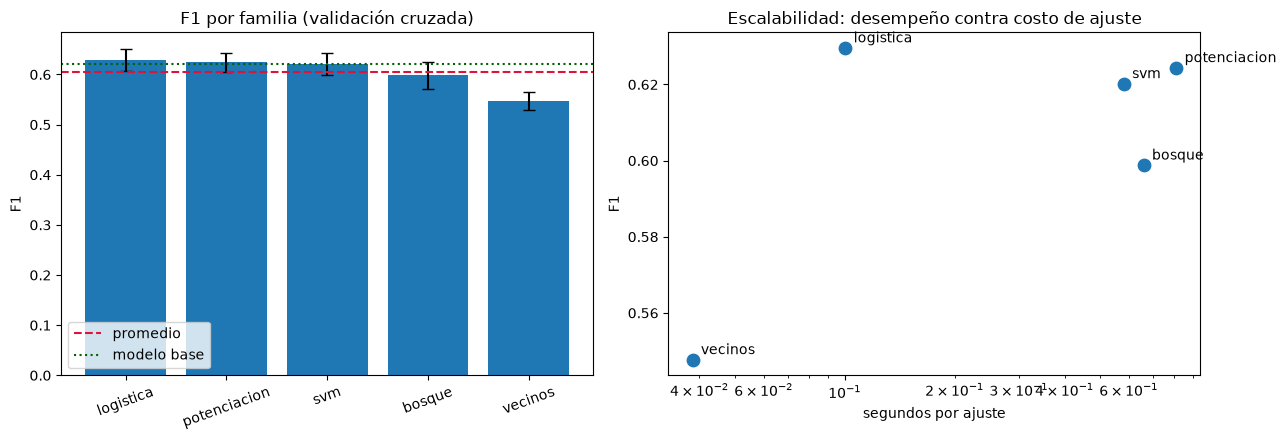

In [5]:
figura, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

orden = tabla_inicial.sort_values("f1_media", ascending=False).index
ejes[0].bar(
    orden,
    tabla_inicial.loc[orden, "f1_media"],
    yerr=tabla_inicial.loc[orden, "f1_desviacion"],
    capsize=4,
)
ejes[0].axhline(promedio_f1, color="crimson", linestyle="--", label="promedio")
ejes[0].axhline(F1_REFERENCIA, color="darkgreen", linestyle=":", label="modelo base")
ejes[0].set_title("F1 por familia (validación cruzada)")
ejes[0].set_ylabel("F1")
ejes[0].legend()
ejes[0].tick_params(axis="x", rotation=20)

ejes[1].scatter(tabla_inicial["segundos_ajuste"], tabla_inicial["f1_media"], s=80)
for nombre in tabla_inicial.index:
    ejes[1].annotate(
        nombre,
        (tabla_inicial.loc[nombre, "segundos_ajuste"], tabla_inicial.loc[nombre, "f1_media"]),
        textcoords="offset points",
        xytext=(6, 4),
    )
ejes[1].set_title("Escalabilidad: desempeño contra costo de ajuste")
ejes[1].set_xlabel("segundos por ajuste")
ejes[1].set_ylabel("F1")
ejes[1].set_xscale("log")

figura.tight_layout()
plt.show()

## 6.4 Optimización de hiperparámetros

Se buscan hiperparámetros solo para las familias que superaron el promedio. La búsqueda es
aleatoria sobre un número acotado de combinaciones, que para espacios de esta dimensión
explora mejor que una rejilla exhaustiva con el mismo presupuesto de cómputo.

El espacio de búsqueda incluye un parámetro del **preprocesamiento**, no solo del
estimador: la opción de descartar un indicador en las categóricas binarias, que el modelo
base dejó señalada como fuente de redundancia. Poder optimizarlo así es una ventaja
directa de tener el preprocesamiento dentro del pipeline.

In [6]:
espacios = {
    "logistica": {
        "modelo__C": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
        "modelo__class_weight": [None, "balanced"],
        "preprocesamiento__categoricas__indicadores__drop": [None, "if_binary"],
    },
    "bosque": {
        "modelo__n_estimators": [200, 400, 600],
        "modelo__max_depth": [5, 10, 20, None],
        "modelo__min_samples_leaf": [1, 5, 10, 20],
        "modelo__max_features": ["sqrt", "log2", 0.5],
        "modelo__class_weight": ["balanced", "balanced_subsample"],
    },
    "potenciacion": {
        "modelo__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "modelo__max_iter": [100, 200, 400],
        "modelo__max_leaf_nodes": [15, 31, 63],
        "modelo__min_samples_leaf": [10, 20, 50],
        "modelo__l2_regularization": [0.0, 0.1, 1.0],
    },
    "svm": {
        "modelo__C": [0.1, 1.0, 10.0],
        "modelo__gamma": ["scale", "auto", 0.01],
    },
    "vecinos": {
        "modelo__n_neighbors": [5, 15, 25, 50],
        "modelo__weights": ["uniform", "distance"],
    },
}

optimizados = {}
resumen_optimizacion = []

for nombre in sobrevivientes:
    busqueda = RandomizedSearchCV(
        construir_pipeline(candidatos[nombre]),
        param_distributions=espacios[nombre],
        n_iter=N_COMBINACIONES,
        scoring="f1",
        cv=validacion,
        random_state=SEMILLA,
        n_jobs=-1,
    )
    busqueda.fit(atributos_ent, objetivo_ent)
    optimizados[nombre] = busqueda.best_estimator_
    resumen_optimizacion.append(
        {
            "modelo": nombre,
            "f1_antes": tabla_inicial.loc[nombre, "f1_media"],
            "f1_despues": busqueda.best_score_,
            "mejora": busqueda.best_score_ - tabla_inicial.loc[nombre, "f1_media"],
        }
    )
    print(f"{nombre}: F1 {busqueda.best_score_:.4f}")
    print(f"  {busqueda.best_params_}")

pd.DataFrame(resumen_optimizacion).set_index("modelo").round(4)

logistica: F1 0.6305
  {'preprocesamiento__categoricas__indicadores__drop': None, 'modelo__class_weight': 'balanced', 'modelo__C': 0.01}


potenciacion: F1 0.6357
  {'modelo__min_samples_leaf': 10, 'modelo__max_leaf_nodes': 15, 'modelo__max_iter': 200, 'modelo__learning_rate': 0.05, 'modelo__l2_regularization': 0.1}


/home/velas/proyectos/telco-churn-mlops/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:327: UserWarning: The total space of parameters 9 is smaller than n_iter=12. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


svm: F1 0.6229
  {'modelo__gamma': 'auto', 'modelo__C': 0.1}


,f1_antes,f1_despues,mejora
modelo,,,
logistica,0.6296,0.6305,0.0009
potenciacion,0.6244,0.6357,0.0113
svm,0.6202,0.6229,0.0027


## 6.5 Comparación estadística

Las desviaciones entre pliegues son del mismo orden que las diferencias entre modelos, así
que declarar ganador al de mayor media sería precipitado.

Se usa la **prueba t pareada con corrección de Nadeau y Bengio**. La prueba t pareada
ordinaria no es válida aquí porque los pliegues comparten datos de entrenamiento entre sí,
lo que viola el supuesto de independencia y subestima la varianza, produciendo diferencias
significativas donde no las hay. La corrección ajusta la varianza por el solapamiento
entre particiones.

In [7]:
puntajes_optimizados = {
    nombre: cross_val_score(modelo, atributos_ent, objetivo_ent, cv=validacion, scoring="f1")
    for nombre, modelo in optimizados.items()
}

n_total = len(atributos_ent)
n_validacion = n_total // N_PLIEGUES
n_entrenamiento = n_total - n_validacion


def prueba_t_corregida(puntajes_a: np.ndarray, puntajes_b: np.ndarray) -> tuple[float, float]:
    """Prueba t pareada con correccion de Nadeau y Bengio para validacion cruzada."""
    diferencias = puntajes_a - puntajes_b
    n = len(diferencias)
    factor = 1 / n + n_validacion / n_entrenamiento
    estadistico = diferencias.mean() / np.sqrt(diferencias.var(ddof=1) * factor)
    valor_p = 2 * distribucion_t.sf(abs(estadistico), n - 1)
    return float(estadistico), float(valor_p)


comparaciones = []
nombres = list(puntajes_optimizados)
for indice, primero in enumerate(nombres):
    for segundo in nombres[indice + 1 :]:
        estadistico, valor_p = prueba_t_corregida(
            puntajes_optimizados[primero], puntajes_optimizados[segundo]
        )
        comparaciones.append(
            {
                "comparacion": f"{primero} vs {segundo}",
                "diferencia_f1": puntajes_optimizados[primero].mean()
                - puntajes_optimizados[segundo].mean(),
                "estadistico_t": estadistico,
                "valor_p": valor_p,
                "significativa": valor_p < ALFA,
            }
        )

pd.DataFrame(comparaciones).round(4)

,comparacion,diferencia_f1,estadistico_t,valor_p,significativa
0,logistica vs potenciacion,-0.0052,-0.5615,0.6044,False
1,logistica vs svm,0.0076,1.7408,0.1567,False
2,potenciacion vs svm,0.0128,1.5209,0.2029,False


In [8]:
resumen_finalistas = pd.DataFrame(
    {
        nombre: {
            "f1_media": puntajes.mean(),
            "f1_desviacion": puntajes.std(),
            "f1_minimo": puntajes.min(),
            "f1_maximo": puntajes.max(),
        }
        for nombre, puntajes in puntajes_optimizados.items()
    }
).T.round(4)

resumen_finalistas.sort_values("f1_media", ascending=False)

,f1_media,f1_desviacion,f1_minimo,f1_maximo
potenciacion,0.6357,0.0118,0.6181,0.6519
logistica,0.6305,0.0208,0.5973,0.6524
svm,0.6229,0.0187,0.5984,0.6441


## 6.6 Selección del modelo

Cuando las diferencias no son estadísticamente significativas, la elección no puede
basarse en la media. El criterio de desempate es operativo: entre modelos equivalentes se
prefiere el más simple, el más rápido de entrenar y el más fácil de interpretar.

In [9]:
tabla_comparaciones = pd.DataFrame(comparaciones)
hay_diferencias = bool(tabla_comparaciones["significativa"].any())

mejor_por_media = resumen_finalistas["f1_media"].idxmax()
mas_rapido = tabla_inicial.loc[sobrevivientes, "segundos_ajuste"].idxmin()

modelo_elegido = mejor_por_media if hay_diferencias else mas_rapido

print(f"¿Alguna diferencia significativa? {hay_diferencias}")
print(f"Mejor por media:  {mejor_por_media}")
print(f"Más rápido:       {mas_rapido}")
print(f"Modelo elegido:   {modelo_elegido}")

pipeline_final = optimizados[modelo_elegido]

¿Alguna diferencia significativa? False
Mejor por media:  potenciacion
Más rápido:       logistica
Modelo elegido:   logistica


## 6.7 Optimización del umbral de decisión

El modelo base mostró que el ROC-AUC no cambia con la ponderación de clases: lo que cambia
es dónde se corta el ordenamiento. El umbral por defecto de 0.5 es arbitrario y no tiene
por qué maximizar el F1.

El umbral se elige sobre predicciones de validación cruzada del conjunto de entrenamiento,
nunca sobre el de prueba: ajustarlo contra los datos de prueba convertiría esa evaluación
en optimista.

In [10]:
probabilidades_cv = cross_val_predict(
    pipeline_final,
    atributos_ent,
    objetivo_ent,
    cv=validacion,
    method="predict_proba",
)[:, 1]

precisiones, exhaustividades, umbrales = precision_recall_curve(objetivo_ent, probabilidades_cv)

f1_por_umbral = np.divide(
    2 * precisiones * exhaustividades,
    precisiones + exhaustividades,
    out=np.zeros_like(precisiones),
    where=(precisiones + exhaustividades) > 0,
)

indice_optimo = int(np.argmax(f1_por_umbral[:-1]))
umbral_optimo = float(umbrales[indice_optimo])

print(f"Umbral óptimo:        {umbral_optimo:.4f}")
print(f"F1 en ese umbral:     {f1_por_umbral[indice_optimo]:.4f}")
print(
    f"F1 con umbral 0.5:    {f1_score(objetivo_ent, (probabilidades_cv >= UMBRAL_DEFECTO).astype(int)):.4f}"
)

Umbral óptimo:        0.5619
F1 en ese umbral:     0.6382
F1 con umbral 0.5:    0.6306


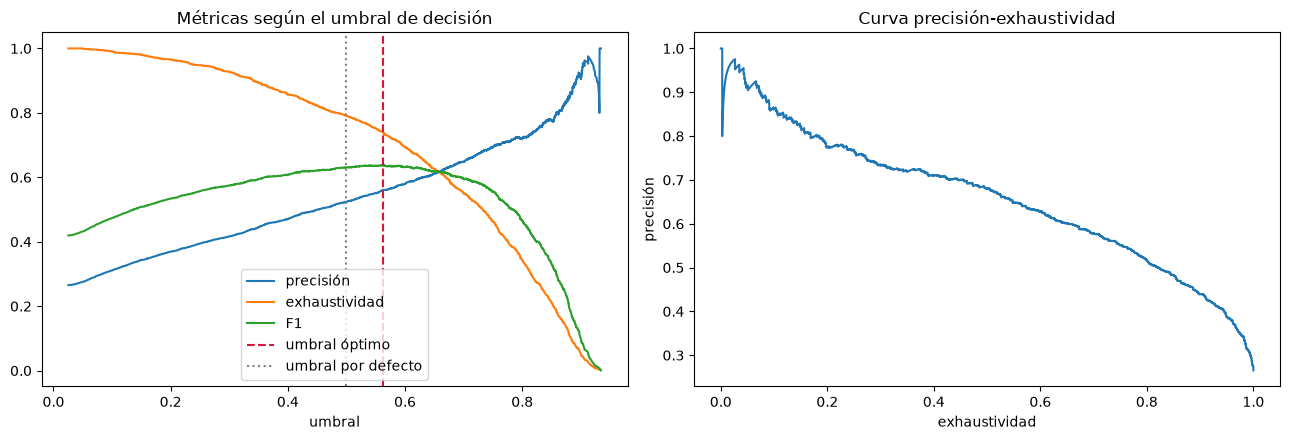

In [11]:
figura, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

ejes[0].plot(umbrales, precisiones[:-1], label="precisión")
ejes[0].plot(umbrales, exhaustividades[:-1], label="exhaustividad")
ejes[0].plot(umbrales, f1_por_umbral[:-1], label="F1")
ejes[0].axvline(umbral_optimo, color="crimson", linestyle="--", label="umbral óptimo")
ejes[0].axvline(UMBRAL_DEFECTO, color="gray", linestyle=":", label="umbral por defecto")
ejes[0].set_title("Métricas según el umbral de decisión")
ejes[0].set_xlabel("umbral")
ejes[0].legend()

ejes[1].plot(exhaustividades, precisiones)
ejes[1].set_title("Curva precisión-exhaustividad")
ejes[1].set_xlabel("exhaustividad")
ejes[1].set_ylabel("precisión")

figura.tight_layout()
plt.show()

## 6.8 Evaluación final sobre el conjunto de prueba

Primera y única vez que se usa el conjunto de prueba. Todo lo anterior, incluidos la
selección de familia, los hiperparámetros y el umbral, se decidió sobre entrenamiento.

In [12]:
pipeline_final.fit(atributos_ent, objetivo_ent)

probabilidades_prueba = pipeline_final.predict_proba(atributos_pru)[:, 1]
prediccion_defecto = (probabilidades_prueba >= UMBRAL_DEFECTO).astype(int)
prediccion_optima = (probabilidades_prueba >= umbral_optimo).astype(int)

resultados_prueba = pd.DataFrame(
    [
        {
            "umbral": "0.50 (por defecto)",
            "precision": precision_score(objetivo_pru, prediccion_defecto),
            "exhaustividad": recall_score(objetivo_pru, prediccion_defecto),
            "f1": f1_score(objetivo_pru, prediccion_defecto),
        },
        {
            "umbral": f"{umbral_optimo:.3f} (optimizado)",
            "precision": precision_score(objetivo_pru, prediccion_optima),
            "exhaustividad": recall_score(objetivo_pru, prediccion_optima),
            "f1": f1_score(objetivo_pru, prediccion_optima),
        },
    ]
).round(4)

print(f"ROC-AUC en prueba: {roc_auc_score(objetivo_pru, probabilidades_prueba):.4f}")
print()
resultados_prueba

ROC-AUC en prueba: 0.8411



,umbral,precision,exhaustividad,f1
0,0.50 (por defecto),0.5087,0.7834,0.6168
1,0.562 (optimizado),0.5395,0.7299,0.6205


In [13]:
print(classification_report(objetivo_pru, prediccion_optima, digits=3))

matriz = confusion_matrix(objetivo_pru, prediccion_optima)
print("Lectura operativa")
print(f"  Cancelaciones detectadas:    {matriz[1, 1]}")
print(f"  Cancelaciones no detectadas: {matriz[1, 0]}")
print(f"  Contactos innecesarios:      {matriz[0, 1]}")

              precision    recall  f1-score   support

           0      0.888     0.775     0.828      1035
           1      0.540     0.730     0.620       374

    accuracy                          0.763      1409
   macro avg      0.714     0.752     0.724      1409
weighted avg      0.796     0.763     0.773      1409

Lectura operativa
  Cancelaciones detectadas:    273
  Cancelaciones no detectadas: 101
  Contactos innecesarios:      233


## 6.9 Análisis de sobreajuste y subajuste

In [14]:
f1_entrenamiento = f1_score(
    objetivo_ent, (pipeline_final.predict_proba(atributos_ent)[:, 1] >= umbral_optimo).astype(int)
)
f1_validacion = puntajes_optimizados[modelo_elegido].mean()
f1_prueba = f1_score(objetivo_pru, prediccion_optima)

diagnostico = pd.DataFrame(
    [
        {"conjunto": "entrenamiento", "f1": f1_entrenamiento},
        {"conjunto": "validación cruzada", "f1": f1_validacion},
        {"conjunto": "prueba", "f1": f1_prueba},
    ]
).round(4)

print(diagnostico.to_string(index=False))
print()
print(f"Brecha entrenamiento-validación: {f1_entrenamiento - f1_validacion:.4f}")
print(f"Brecha validación-prueba:        {f1_validacion - f1_prueba:.4f}")

          conjunto     f1
     entrenamiento 0.6377
validación cruzada 0.6305
            prueba 0.6205

Brecha entrenamiento-validación: 0.0072
Brecha validación-prueba:        0.0100


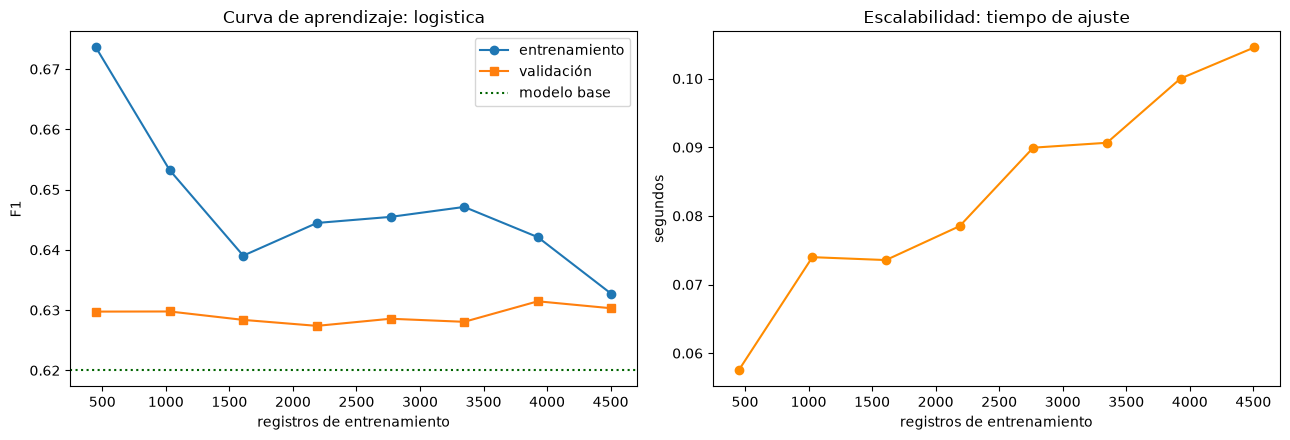

In [15]:
tamanos, puntaje_ent, puntaje_val, tiempos, _ = learning_curve(
    pipeline_final,
    atributos_ent,
    objetivo_ent,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=validacion,
    scoring="f1",
    return_times=True,
    random_state=SEMILLA,
    n_jobs=-1,
)

figura, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

ejes[0].plot(tamanos, puntaje_ent.mean(axis=1), marker="o", label="entrenamiento")
ejes[0].plot(tamanos, puntaje_val.mean(axis=1), marker="s", label="validación")
ejes[0].axhline(F1_REFERENCIA, color="darkgreen", linestyle=":", label="modelo base")
ejes[0].set_title(f"Curva de aprendizaje: {modelo_elegido}")
ejes[0].set_xlabel("registros de entrenamiento")
ejes[0].set_ylabel("F1")
ejes[0].legend()

ejes[1].plot(tamanos, tiempos.mean(axis=1), marker="o", color="darkorange")
ejes[1].set_title("Escalabilidad: tiempo de ajuste")
ejes[1].set_xlabel("registros de entrenamiento")
ejes[1].set_ylabel("segundos")

figura.tight_layout()
plt.show()

## 6.10 Persistencia del modelo

Se guarda el pipeline completo ajustado: preprocesamiento y estimador en un único objeto.
Es lo que consumirán el pipeline de inferencia y la aplicación de despliegue, y garantiza
que las transformaciones aplicadas en producción sean exactamente las del entrenamiento.

Junto al modelo se guardan sus metadatos. El umbral de decisión es especialmente
importante: sin él, quien cargue el modelo usaría el corte por defecto y obtendría un
comportamiento distinto al evaluado aquí.

In [16]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(pipeline_final, MODELO_FILE)

metadatos = {
    "familia": modelo_elegido,
    "umbral_decision": round(umbral_optimo, 6),
    "columnas_entrada": atributos.columns.tolist(),
    "metricas_prueba": {
        "f1": round(float(f1_prueba), 4),
        "precision": round(float(precision_score(objetivo_pru, prediccion_optima)), 4),
        "exhaustividad": round(float(recall_score(objetivo_pru, prediccion_optima)), 4),
        "roc_auc": round(float(roc_auc_score(objetivo_pru, probabilidades_prueba)), 4),
    },
    "f1_modelo_base": F1_REFERENCIA,
    "semilla": SEMILLA,
}

METADATOS_FILE.write_text(json.dumps(metadatos, indent=2, ensure_ascii=False))

print(f"Modelo:    {MODELO_FILE.name} ({MODELO_FILE.stat().st_size / 1024:.1f} KB)")
print(f"Metadatos: {METADATOS_FILE.name}")
print()
print(json.dumps(metadatos["metricas_prueba"], indent=2))

Modelo:    modelo_churn.joblib (9.5 KB)
Metadatos: modelo_churn_metadatos.json

{
  "f1": 0.6205,
  "precision": 0.5395,
  "exhaustividad": 0.7299,
  "roc_auc": 0.8411
}


In [17]:
modelo_recuperado = joblib.load(MODELO_FILE)
prediccion_recuperada = modelo_recuperado.predict_proba(atributos_pru)[:, 1]

assert np.allclose(prediccion_recuperada, probabilidades_prueba), "Predicciones distintas"

print("El modelo recuperado del disco reproduce las mismas probabilidades")

El modelo recuperado del disco reproduce las mismas probabilidades


## 6.11 Conclusiones

### Resultado principal: el modelo seleccionado no mejora al modelo base

| Modelo | F1 en prueba |
|---|---|
| Modelo base (logistica ponderada, sin optimizar) | 0.620 |
| Modelo seleccionado (logistica optimizada, umbral 0.562) | 0.6205 |

Cinco familias evaluadas, optimizacion de hiperparametros sobre las tres finalistas y
ajuste del umbral de decision, para una diferencia de cinco diezmilesimas. En terminos
practicos, **el aprendizaje automatico no aporta sobre la referencia establecida**.

Este resultado no contradice el trabajo previo, lo confirma. Dos evidencias apuntaban
aqui: la curva de aprendizaje del modelo base era plana, con brecha de 0.0053, senal de
que el limite no era el volumen de datos; y el analisis exploratorio encontro que el 6.1%
de los registros pertenece a perfiles de servicio con desenlace ambiguo. Hay un techo
impuesto por la informacion disponible, y los cinco modelos chocaron contra el.

Una tercera senal lo refuerza: la busqueda de hiperparametros eligio `C=0.01`, una
regularizacion fuerte. El modelo obtiene su mejor desempeno cuando se le impide ajustarse
a los datos, que es lo esperable cuando hay poca senal que extraer.

### Evaluacion de las familias

| Familia | F1 inicial | Desviacion | Segundos por ajuste | Resultado |
|---|---|---|---|---|
| Logistica | 0.6296 | 0.0219 | 0.10 | Finalista |
| Potenciacion | 0.6244 | 0.0190 | 0.72 | Finalista |
| SVM | 0.6202 | 0.0220 | 2.77 | Finalista |
| Bosque | 0.5988 | 0.0271 | 0.81 | Descartada |
| Vecinos | 0.5477 | 0.0177 | 0.04 | Descartada |

El promedio del conjunto fue 0.6041. Bosque y vecinos quedaron por debajo y no pasaron a
la optimizacion.

Un resultado llamativo: **la familia mas simple fue tambien la mejor**. La expectativa del
modelo base era que los arboles aprovecharan la interaccion entre contrato y antiguedad
que mostro el analisis exploratorio. No ocurrio. La explicacion mas plausible es que esa
interaccion ya esta disponible para el modelo lineal: el pipeline de atributos incluye la
antiguedad discretizada en tramos, y esos indicadores permiten a un modelo lineal
representar el efecto por segmento sin necesidad de particiones recursivas.

### La prueba estadistica cambio la decision

Tras la optimizacion, el orden por media era: potenciacion 0.6357, logistica 0.6305, svm
0.6229. Elegir por media habria seleccionado la potenciacion.

La prueba t corregida arrojo valores p de 0.60, 0.16 y 0.20 en las tres comparaciones.
**Ninguna diferencia es estadisticamente significativa.** Con desviaciones entre pliegues
del orden de 0.02, una diferencia de 0.005 entre medias es ruido, y declarar un ganador
sobre esa base habria sido un error de metodo.

El criterio de desempate se fijo antes de ejecutar: a igualdad estadistica se prefiere el
modelo mas simple y de menor costo de ajuste. Ese criterio selecciona la regresion
logistica, que ademas se ajusta veintiocho veces mas rapido que la maquina de vectores de
soporte y siete veces mas rapido que la potenciacion.

Conviene ser explicito en un punto: si el criterio de desempate hubiera sido la
estabilidad entre pliegues en lugar de la simplicidad, la eleccion habria sido la
potenciacion, que tiene menor desviacion (0.0118 frente a 0.0208) y mejor peor caso
(0.6181 frente a 0.5973). Ambos criterios son defendibles; lo que no seria defendible es
escoger el criterio despues de ver cual favorece al modelo que uno prefiere.

### Umbral de decision

El umbral optimo resulto 0.562, no 0.5. La ganancia en validacion cruzada fue de 0.6306 a
0.6382, y en prueba de 0.6168 a 0.6205. Modesta, pero el efecto sobre el equilibrio
operativo es mayor que sobre la metrica: desplaza el reparto entre cancelaciones
detectadas y contactos innecesarios.

### Desempeno final sobre el conjunto de prueba

| Metrica | Valor |
|---|---|
| ROC-AUC | 0.8411 |
| F1 sobre la clase de fuga | 0.6205 |
| Precision | 0.5395 |
| Exhaustividad | 0.7299 |

Lectura operativa sobre 374 cancelaciones reales: detecta 273, deja escapar 101, y genera
233 contactos innecesarios. Por cada cien clientes marcados, cincuenta y cuatro iban
efectivamente a cancelar.

### Sin sobreajuste ni subajuste

Las brechas son de 0.0072 entre entrenamiento y validacion cruzada, y de 0.0100 entre
validacion y prueba. El modelo generaliza sin deterioro apreciable y no memoriza los datos
de entrenamiento. Tampoco hay subajuste por capacidad insuficiente: familias con mucha mas
capacidad, como la potenciacion del gradiente, no obtuvieron mas.

### Recomendaciones

1. **No buscar mas modelos ni mas datos.** Cinco familias convergieron al mismo techo y la
   curva de aprendizaje es plana. Insistir por esa via no va a producir mejoras.
2. **La via de mejora son atributos nuevos**: historial de reclamos, calidad de servicio
   percibida, interacciones con soporte, ofertas de la competencia. Esa informacion
   explicaria los perfiles ambiguos que hoy limitan el desempeno.
3. **Tratar el umbral como parametro de negocio configurable**, no como constante del
   modelo. Debe poder ajustarse segun la capacidad del equipo de retencion sin reentrenar.
4. **El valor del modelo esta en el ordenamiento, no en la clasificacion binaria.** Un
   ROC-AUC de 0.84 permite priorizar una lista de clientes de forma util, aunque el corte
   binario no supere a la referencia.
5. **Conservar la logistica** tambien por operacion: se ajusta en decimas de segundo, lo
   que abarata el reentrenamiento periodico, y sus coeficientes son directamente
   interpretables, lo que facilita justificar cada decision ante el area comercial.

**Siguiente paso:** interpretacion del modelo seleccionado y analisis de sus errores.